<img src="https://news.weill.cornell.edu/sites/default/files/styles/news_story_featured_image/public/story_featured_images/shutterstock_1561133012.jpg?itok=_c6CkDfd&c=88372c024f5dcbdb2272c91d77deed96">

# **Project Description**

##  LungGuard AI

LungGuard AI is an intelligent deep learning system designed to analyze **chest X-ray images** and classify lung conditions into three categories: Normal, Pneumonia, and COVID-19.

The system not only predicts the disease type but also provides a confidence score, determines the patient's health status (Healthy / Not Healthy), and estimates the risk level based on model certainty.

To enhance reliability, the system incorporates an uncertainty-aware mechanism that detects low-confidence predictions and prompts the user to upload a clearer chest X-ray image when necessary.

Additionally, explainable AI techniques (such as heatmaps) are used to highlight the regions in the chest X-ray that influenced the model's decision, improving transparency and trust.

---

##  Dataset Description

The dataset used in this project is a combination of publicly available **chest X-ray datasets**:

* **Chest X-Ray Pneumonia Dataset (Kaggle)**

  * Contains labeled chest X-ray images for Normal and Pneumonia cases

* **COVID-19 Radiography Database (Kaggle)**

  * Used to extract COVID-19 chest X-ray images

---

##  Key Features

* Multi-class classification (Normal / Pneumonia / COVID-19)
* Confidence score for each prediction
* Health status detection (Healthy vs Not Healthy)
* Risk level estimation
* Uncertainty handling (low-confidence detection)
* Explainable AI visualization (heatmaps on chest X-rays)

---

##  Objective

The goal of this project is to simulate a real-world AI-powered decision support system that assists in early detection of lung diseases using chest X-ray imaging, while ensuring transparency, reliability, and usability.


# **The Code Pipline**
* Data Cleaning
* Visualization
* Preprocessing (Resize + RGB )
* Data Splitting
* Normalization
* Data Augmentation (Train Only)
* Modeling (CNN & Transfer Learning)
* Evaluation
* Uncertainty Handling
* Testing on New Data
* Save Model

**1- Data Cleaning**

**Step Description**
* Data cleaning by removing invalid images (wrong formats or corrupted files) to ensure that only clean and valid data is used for model training.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Main library use

import cv2
# Used for image and video processing such as reading, editing images, and face detection
import imghdr
# Used to detect the image file type and verify that a file is a valid image
import os
# Used to work with files, folders, and system paths
import numpy as np
# Used for numerical operations and handling arrays, including image data
from matplotlib import pyplot as plt
# Used for displaying images and plotting graphs
import tensorflow as tf
# Used to build and train deep learning and artificial intelligence models, especially neural networks, for image, audio, and data processing.


/tmp/ipykernel_1307/1219155289.py:5: DeprecationWarning: 'imghdr' is deprecated and slated for removal in Python 3.13
  import imghdr


In [3]:
# donlowed data
data_dir ="/content/drive/MyDrive/Data3"
# possible extentation
image_extensions = ['jpg', 'jpeg', 'png', 'bmp', 'tiff', 'tif', 'webp']

# Loop for the main classes
for image_class in os.listdir(data_dir):
  class_path = os.path.join(data_dir, image_class)
  # loop for images in the main classes
  for image in os.listdir(class_path):
    image_path = os.path.join(class_path, image)
    image_ext = imghdr.what(image_path)

    # Check the Extension for each image
    if image_ext not in image_extensions:
      os.remove(image_path)
      continue


    # Check if the image is correct or not if not delete
    try:
      image = cv2.imread(image_path)
      if image is None:
        os.remove(image_path)
    except Exception as e:
      print(f"Error processing image {image_path}: {e}")

print("Done")

Done


**Insight**
* Data quality is more important than the model itself — if your data is noisy or corrupted, even the best model will learn incorrectly.

**2- Visualization**

Step Description
**bold text*** Displaying random samples from each class to understand the data and verify its correctness before training the model.

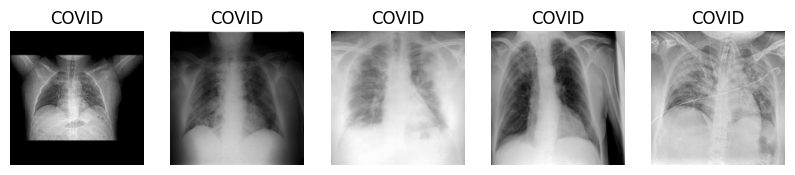

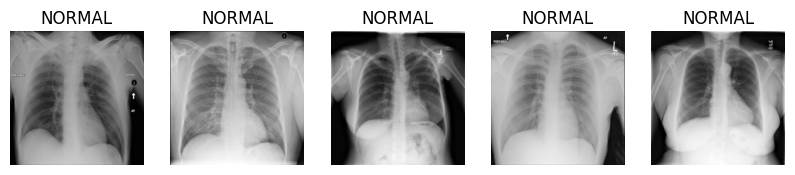

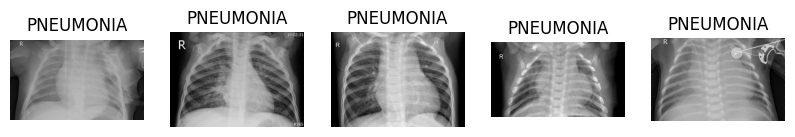

In [4]:
# Import
import random
from PIL import Image

# main fun
def show_samples(data_dir, class_name):
    class_path = os.path.join(data_dir, class_name)
    images = os.listdir(class_path)

    # chose five images by random
    sample = random.sample(images, 5)

    # Note => enumerate return the value and the index
    plt.figure(figsize=(10,3))
    for i, img_name in enumerate(sample):
        img_path = os.path.join(class_path, img_name)
        img = Image.open(img_path)

        plt.subplot(1,5,i+1)
        plt.imshow(img, cmap='gray')
        plt.title(class_name)
        plt.axis('off')

    plt.show()

for cls in ["COVID","NORMAL","PNEUMONIA"]:
    show_samples(data_dir, cls)

**Insight**
* The real difference between classes is not the overall shape, but the distribution of brightness (white regions) inside the lungs — this is a key feature the model relies on.
* There is high similarity between COVID and Pneumonia, meaning the model needs strong and diverse data to distinguish between them accurately.
* The Normal class is clear and easier, so the model will likely achieve high accuracy on it — the real challenge lies in distinguishing between disease cases.
* Differences in image zoom levels and cropping were observed

**3- Preprocessing (Resize + RGB)**


**Step Description**
* Preparing images by resizing them, loading them into a dataset.

In [6]:
# Fixed size
img_size = 224

for image_class in os.listdir(data_dir):
    class_path = os.path.join(data_dir, image_class)

    # Ensure it's a directory
    if not os.path.isdir(class_path):
        continue

    for image in os.listdir(class_path):
        image_path = os.path.join(class_path, image)

        try:
            # Read image
            img = cv2.imread(image_path)

            # Check if image is corrupted
            if img is None:
                print(f"Corrupted: {image_path}")
                continue

            # Convert img to RGB
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            # Resize image
            img = cv2.resize(img, (img_size, img_size), interpolation=cv2.INTER_AREA)

        except Exception as e:
            print(f"Error processing image {image_path}: {e}")

print("Done")

Done


**Insight**
* Resizing images is not optional — it’s mandatory for the model to work.


**4- Data spliting**


**Step Description**
* The dataset was split into Training (70%) and Validation (30%) using validation_split, then the validation set was further divided into Validation (15%) and **Test (15%). This approach ensures fair evaluation on unseen data and helps prevent **data leakage**, which can occur when using improper splitting methods such as shuffle + take/skip`.

In [7]:
# # It loads images from organized folders, automatically assigns labels, and converts them into a dataset ready for training a deep learning model.
# # The Output is the image and the label

# Train
train_data = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.3,
    subset="training",
    seed=42,
    image_size=(224, 224),
    batch_size=32
)

# Val
val_data = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.3,
    subset="validation",
    seed=42,
    image_size=(224, 224),
    batch_size=32
)

# Split val → val + test
val_batches = len(val_data)

test_data = val_data.take(val_batches // 2)
val_data  = val_data.skip(val_batches // 2)

print("Done")

Found 10500 files belonging to 3 classes.
Using 7350 files for training.
Found 10500 files belonging to 3 classes.
Using 3150 files for validation.
Done


In [8]:
print(train_data.class_names)

['COVID', 'NORMAL', 'PNEUMONIA']


**5-Normalization**
* Normalizing pixel values to [0,1] for efficient model training.

In [9]:
# Normalization data for CNN
train_data = train_data.map(lambda x, y: (x / 255.0, y))
val_data = val_data.map(lambda x, y: (x / 255.0, y))
test_data = test_data.map(lambda x, y: (x / 255.0, y))

In [61]:
# Code to ensure if there is overloap between train and test data.

train_paths = []
test_paths = []

for images, labels in train_data.unbatch():
    train_paths.append(images.numpy().tobytes())

for images, labels in test_data.unbatch():
    test_paths.append(images.numpy().tobytes())

common = set(train_paths) & set(test_paths)

print("Number of overlapping images:", len(common))

Number of overlapping images: 13


**Insight**
* Normalization makes training faster and more stable — without it, the model may struggle to learn.
* The validation set determines whether the model is improving or overfitting — not the training accuracy.
* The test set must remain untouched until the end — it’s the true measure of real-world performance.

**5- Augmentation**

**Step Description**
* Increasing data diversity by applying random transformations during training to improve model generalization.

In [ ]:
# # Define augmentation pipeline
# data_augmentation = tf.keras.Sequential([
#     tf.keras.layers.RandomFlip("horizontal"),
#     tf.keras.layers.RandomRotation(0.03),
#     tf.keras.layers.RandomZoom(0.05),
#     tf.keras.layers.RandomTranslation(0.05, 0.05),
# ])

# print("Done")

In [11]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.15),
    tf.keras.layers.RandomTranslation(0.1, 0.1),
    tf.keras.layers.RandomContrast(0.2),
    tf.keras.layers.GaussianNoise(0.05),
])
print("Done")

Done


**Insight**
* Data augmentation exposes the model to multiple variations of the same image, reducing overfitting significantly.
* In medical imaging, augmentation must be subtle — strong transformations can distort the medical meaning.

Note => Augmentation doesn’t increase dataset size physically, but increases the diversity seen during training.

**6- Modelling**

In [24]:
# Import - CNN
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, GlobalAveragePooling2D ,BatchNormalization ,Flatten
from tensorflow.keras.layers import Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Evaluation
from sklearn.metrics import classification_report
from tensorflow.keras.metrics import Precision , Recall
from sklearn.metrics import confusion_matrix



1- CNN

In [25]:
model = Sequential()

# Block 1
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D())

# Block 2
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D())

# Block 3
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D())

# Block 4
model.add(Conv2D(256, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D())

model.add(Flatten())

# Dense
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(3, activation='softmax'))

In [26]:
# Prepares the model for training by defining three main components:
# Optimizer: Updates the model weights
#Loss: Measures the error
# Metrics: Evaluate the model performance

# Change from .001 to .0003
optimizer = Adam(learning_rate=0.0003)

model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [27]:
# Model Summary
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     9,437,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,828,547 (37.49 MB)

 Trainable params: 9,827,587 (37.49 MB)

 Non-trainable params: 960 (3.75 KB)

In [28]:

# EarlyStopping → stops training when no improvement
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Checkpoint → saves the best model
checkpoint = ModelCheckpoint(
    'best_model.h5',
    monitor='val_loss',
    save_best_only=True
)

In [29]:

# class_weight = {
#     0: 1.0,
#     1: 0.95,
#     2: 1.5
# }

# We use class_weight to make the model focus more on difficult or important classes by increasing the penalty for mistakes.
# Note => The first num is the class and the second is the weight


class_weight = {
    0: 1.1,        # Covid
    1: 2.2,       # Normal
    2: 1.0         # Pneumonia
}
# fittin
history = model.fit(train_data,validation_data=val_data,epochs=20,callbacks=[ early_stop, checkpoint] , class_weight=class_weight)

Epoch 1/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - accuracy: 0.7657 - loss: 2.1083

230/230 ━━━━━━━━━━━━━━━━━━━━ 77s 283ms/step - accuracy: 0.8388 - loss: 0.9919 - val_accuracy: 0.4804 - val_loss: 5.3583
Epoch 2/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 56s 244ms/step - accuracy: 0.8986 - loss: 0.3685 - val_accuracy: 0.5771 - val_loss: 5.4724
Epoch 3/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - accuracy: 0.9179 - loss: 0.2919

230/230 ━━━━━━━━━━━━━━━━━━━━ 56s 245ms/step - accuracy: 0.9226 - loss: 0.2782 - val_accuracy: 0.9298 - val_loss: 0.1781
Epoch 4/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 57s 247ms/step - accuracy: 0.9408 - loss: 0.2306 - val_accuracy: 0.8458 - val_loss: 0.9646
Epoch 5/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 56s 244ms/step - accuracy: 0.9420 - loss: 0.2318 - val_accuracy: 0.5917 - val_loss: 9.0631
Epoch 6/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 56s 244ms/step - accuracy: 0.9468 - loss: 0.2410 - val_accuracy: 0.6960 - val_loss: 1.5996
Epoch 7/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 59s 258ms/step - accuracy: 0.9537 - loss: 0.1816 - val_accuracy: 0.9330 - val_loss: 0.2080
Epoch 8/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 83s 263ms/step - accuracy: 0.9576 - loss: 0.1739 - val_accuracy: 0.7788 - val_loss: 2.8824


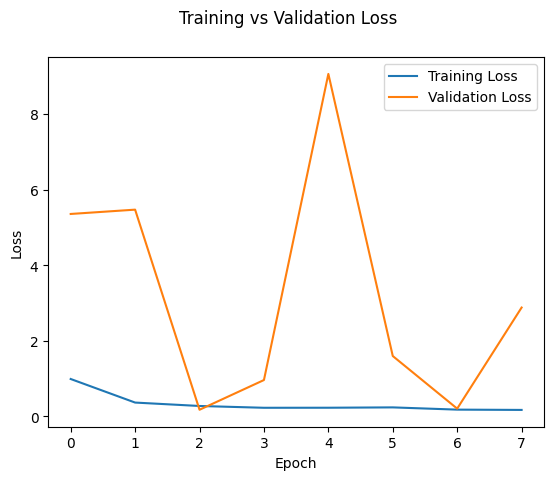

In [30]:
#  display loss
fig = plt.figure()

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

fig.suptitle("Training vs Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(loc="upper right")
plt.show()

**7- Evaluation**

In [31]:
# Model evaluation
loss, acc = model.evaluate(val_data)

print("Validation Loss:", loss)
print("Validation Accuracy:", acc)

50/50 ━━━━━━━━━━━━━━━━━━━━ 16s 169ms/step - accuracy: 0.9330 - loss: 0.1719
Validation Loss: 0.17186623811721802
Validation Accuracy: 0.9329962134361267


In [32]:
# Confusion matrix

y_true = []
y_pred = []

for images, labels in val_data:
    preds = model.predict(images)

    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

from sklearn.metrics import confusion_matrix

con_matrix = confusion_matrix(y_true, y_pred)
print(con_matrix)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━

In [33]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names = ["COVID","NORMAL","PNEUMONIA"]
))

              precision    recall  f1-score   support

       COVID       0.87      0.95      0.91       523
      NORMAL       0.94      0.87      0.90       530
   PNEUMONIA       1.00      0.97      0.98       529

    accuracy                           0.93      1582
   macro avg       0.93      0.93      0.93      1582
weighted avg       0.93      0.93      0.93      1582



**7- Uncertainty Handling**

In [ ]:

class_names = ['covid', 'normal', 'pneumonia']

def predict_with_uncertainty(model, img, threshold=0.8):

    preds = model.predict(img)

    confidence = np.max(preds)
    class_index = np.argmax(preds)
    label = class_names[class_index]

    # Risk level
    if confidence >= 0.9:
        risk = "High Confidence"
    elif confidence >= 0.7:
        risk = "Medium Confidence"
    else:
        risk = "Low Confidence"

    # Decision
    if confidence < 0.5:
        decision = "Invalid Image . This may not be a chest X-ray or not one of the supported diseases."

    elif confidence < threshold:
        decision = "Uncertain . Please upload a clearer chest X-ray image."

    else:
        decision = "Prediction OK "

    return label, confidence, risk, decision

**8- Testing & Evaluation on  test_data**

In [34]:
# CNN
loss, acc = model.evaluate(test_data)

print("Test Loss:", loss)
print("Test Accuracy:", acc)

49/49 ━━━━━━━━━━━━━━━━━━━━ 7s 150ms/step - accuracy: 0.9324 - loss: 0.1886
Test Loss: 0.18859098851680756
Test Accuracy: 0.9323979616165161


In [35]:
y_true = []
y_pred = []

for images, labels in test_data:
    preds = model.predict(images)

    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)
print(cm)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms

In [37]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names = ["COVID","NORMAL","PNEUMONIA"]
))

              precision    recall  f1-score   support

       COVID       0.87      0.95      0.91       510
      NORMAL       0.93      0.88      0.90       520
   PNEUMONIA       1.00      0.97      0.98       538

    accuracy                           0.93      1568
   macro avg       0.93      0.93      0.93      1568
weighted avg       0.94      0.93      0.93      1568



**9- Model Deplyment**

1- Save Model

In [41]:
# Save CNN
model.save("lung_model_cnn.keras")

2- Display Models in GUI

In [ ]:
!pip install streamlit

In [38]:
%%writefile new_app.py
import streamlit as st
import tensorflow as tf
import numpy as np
from PIL import Image

#  Load CNN Model
model = tf.keras.models.load_model("lung_model_cnn.keras")

class_names = ['covid', 'normal', 'pneumonia']

#  Uncertainty Function
def predict_with_uncertainty(model, img, threshold=0.8):

    preds = model.predict(img)[0]

    confidence = np.max(preds)
    class_index = np.argmax(preds)
    label = class_names[class_index]

    # Risk Level
    if confidence >= 0.9:
        risk = "High Confidence"
    elif confidence >= 0.7:
        risk = "Medium Confidence"
    else:
        risk = "Low Confidence"

    # Decision
    if confidence < 0.6:
        decision = "⚠️ Uncertain Prediction - Please upload a clearer image"
    elif confidence < threshold:
        decision = "⚠️ Medium Confidence - Please verify result"
    else:
        decision = "✅ Prediction OK"

    return label, confidence, risk, decision, preds


#  TITLE
st.title("🫁 LungGuard AI")

# 📖 PROJECT DESCRIPTION
st.markdown("""
### 📌 About the Project

**LungGuard AI** is an intelligent deep learning system designed to analyze chest X-ray images and classify lung conditions into:

- 🟢 Normal
- 🟡 Pneumonia
- 🔴 COVID-19

The system provides:
- 📊 Confidence score
- ❤️ Health status
- ⚠️ Risk level

It also includes an uncertainty-aware mechanism to detect low-confidence predictions.

⚠️ **Disclaimer:** This system is for educational purposes only and not a medical diagnosis.
""")

# 📤 Upload Image
uploaded_file = st.file_uploader("📤 Upload Chest X-ray Image", type=["jpg", "png", "jpeg"])

if uploaded_file is not None:

    # 🖼️ Show Image
    image = Image.open(uploaded_file).convert("RGB")
    st.image(image, caption="Uploaded Image", use_column_width=True)

    #  Preprocessing
    # =========================
    img = image.resize((224, 224))
    img = np.array(img)
    img = img / 255.0
    img = np.expand_dims(img, axis=0)

    #  Prediction + Uncertainty
    label, confidence, risk, decision, probs = predict_with_uncertainty(model, img)

    # ❤️ Health Status (محسن)
    health_status = "Healthy" if label == "normal" else "Needs Medical Review"

    # 📊 RESULTS
    st.subheader("🔍 Results")

    st.write(f"**Prediction:** {label}")
    st.write(f"**Confidence:** {confidence:.2f}")
    st.write(f"**Health Status:** {health_status}")
    st.write(f"**Risk Level:** {risk}")
    st.write(f"**Decision:** {decision}")

    # 📊 Class Probabilities
    st.subheader("📊 Class Probabilities")

    for i, class_name in enumerate(class_names):
        st.write(f"{class_name}: {probs[i]:.2f}")

    st.bar_chart(probs)

    # 💡 INSIGHT
    st.subheader("💡 Insight")

    if label == "covid":
        st.write("""
        The model detected **diffuse white patterns** across the lungs, which are commonly associated with COVID-19.
        """)

    elif label == "pneumonia":
        st.write("""
        The model identified **localized opacities** in specific lung regions, typical of Pneumonia.
        """)

    else:
        st.write("""
        The lungs appear **clear with no abnormal patterns**, indicating a normal condition.
        """)

Writing new_app.py


In [42]:
import os

print(os.listdir())

['.config', 'best_model.h5', 'drive', 'lung_model_cnn.keras', 'new_app.py', 'sample_data']


In [43]:
from google.colab import files

files.download('/content/lung_model_cnn.keras')
files.download('/content/new_app.py')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>